In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Termination criteria
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
calibration_flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC + cv2.fisheye.CALIB_FIX_SKEW

# Inner size of chessboard
width = 9
height = 6
square_size = 0.025  # 0.025 meters

# Prepare object points
objp = np.zeros((height * width, 1, 3), np.float64)
objp[:, 0, :2] = np.mgrid[0:width, 0:height].T.reshape(-1, 2)
objp = objp * square_size  # Create real-world coordinates

# Arrays to store object points and image points
objpoints = []  # 3D points in real-world space
imgpoints = []  # 2D points in image plane

# Image parameters
img_width = 640
img_height = 480
image_size = (img_width, img_height)

# Image directory
path = ""
image_dir = path + "pairs/"
number_of_images = 50

# Process images
for i in range(1, number_of_images):
    # Read image
    img = cv2.imread(image_dir + "left_%02d.png" % i)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Find the chessboard corners
    ret, corners = cv2.findChessboardCorners(
        gray, (width, height),
        cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE
    )

    # Skip images where corners are too close to edges
    Y, X, channels = img.shape
    if ret:
        minRx = corners[:, :, 0].min()
        maxRx = corners[:, :, 0].max()
        minRy = corners[:, :, 1].min()
        maxRy = corners[:, :, 1].max()
        border_threshold_x = X / 12
        border_threshold_y = Y / 12
        x_thresh_bad = minRx < border_threshold_x
        y_thresh_bad = minRy < border_threshold_y
        if x_thresh_bad or y_thresh_bad:
            continue

        # Add object points and refine image points
        objpoints.append(objp)
        corners2 = cv2.cornerSubPix(gray, corners, (3, 3), (-1, -1), criteria)
        imgpoints.append(corners2)

        # Draw and display the corners
        cv2.drawChessboardCorners(img, (width, height), corners2, ret)
        cv2.imshow("Corners", img)
        cv2.waitKey(5)
    else:
        print("Chessboard couldn’t be detected. Image pair:", i)
        continue


In [3]:

# Calibration
N_OK = len(objpoints)
K = np.zeros((3, 3))
D = np.zeros((4, 1))
rvecs = [np.zeros((1, 1, 3), dtype=np.float64) for _ in range(N_OK)]
tvecs = [np.zeros((1, 1, 3), dtype=np.float64) for _ in range(N_OK)]

ret, K, D, _, _ = cv2.fisheye.calibrate(
    objpoints, imgpoints, image_size, K, D, rvecs, tvecs,
    calibration_flags,
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-6)
)

# Rectify results
map1, map2 = cv2.fisheye.initUndistortRectifyMap(
    K, D, np.eye(3), K, image_size, cv2.CV_16SC2
)

In [4]:
print("błąd średniokwadratowej projekcji wstecznej: ", ret)
print("K macierz wewnętrzna kamery: \n", K)
print("D współczynniki dystorsji: \n", D)
print("rvecs wektory rotacji: \n", rvecs)
print("tvecs wektory translacji: \n", tvecs)

błąd średniokwadratowej projekcji wstecznej:  0.11462940990068468
K macierz wewnętrzna kamery: 
 [[335.39124594   0.         345.29455183]
 [  0.         335.22283549 232.92700067]
 [  0.           0.           1.        ]]
D współczynniki dystorsji: 
 [[-0.02430673]
 [-0.018878  ]
 [ 0.02584017]
 [-0.01508828]]
rvecs wektory rotacji: 
 [array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0., 0., 0.]]]), array([[[0

In [5]:
test_image_path = image_dir + "left_01.png"
test_img = cv2.imread(test_image_path)



undistorted_image = cv2.remap(test_img, map1, map2, interpolation = cv2.INTER_LINEAR, borderMode = cv2.BORDER_CONSTANT )
# cv2.imshow("Original Image", test_img)
# cv2.imshow("Undistorted Image", undistorted_image)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

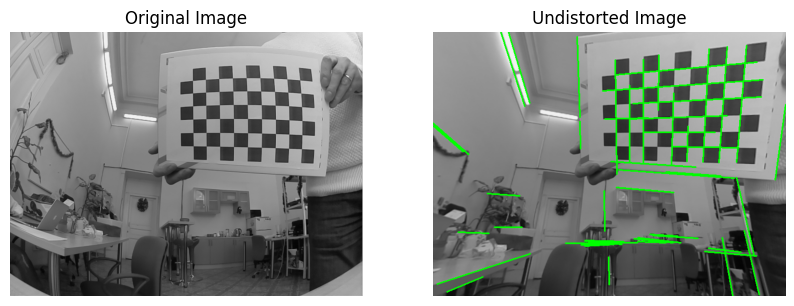

In [6]:
def detect_lines(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 100, minLineLength=50, maxLineGap=10)
    return lines

def draw_lines(image, lines):
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

lines_before = detect_lines(test_img)
lines_after = detect_lines(undistorted_image)

draw_lines(img, lines_before)
draw_lines(undistorted_image, lines_after)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original Image")
ax[0].axis("off")
ax[1].imshow(cv2.cvtColor(undistorted_image, cv2.COLOR_BGR2RGB))
ax[1].set_title("Undistorted Image")
ax[1].axis("off")
plt.show()

Kalibracja dla wsxzystkich obrazów:

In [8]:
test_image_path = image_dir + "left_01.png"
test_img = cv2.imread(test_image_path)
number_of_images = 50
corected_images_right = []
corected_images_left = []

for i in range(1, number_of_images):
    test_image_path = image_dir + "left_%02d.png" % i
    test_img = cv2.imread(test_image_path)
    undistorted_image = cv2.remap(test_img, map1, map2, interpolation = cv2.INTER_LINEAR, borderMode = cv2.BORDER_CONSTANT )
    corected_images_left.append((test_img, undistorted_image))

for i in range(1, number_of_images):
    test_image_path = image_dir + "right_%02d.png" % i
    test_img = cv2.imread(test_image_path)
    undistorted_image = cv2.remap(test_img, map1, map2, interpolation = cv2.INTER_LINEAR, borderMode = cv2.BORDER_CONSTANT )
    corected_images_right.append((test_img, undistorted_image))

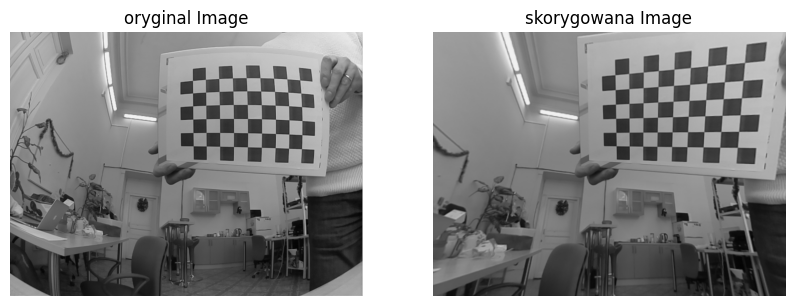

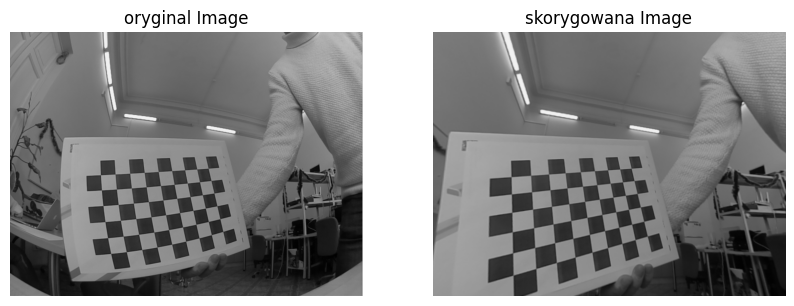

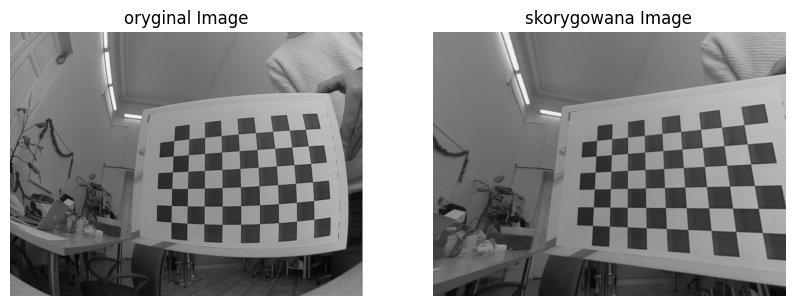

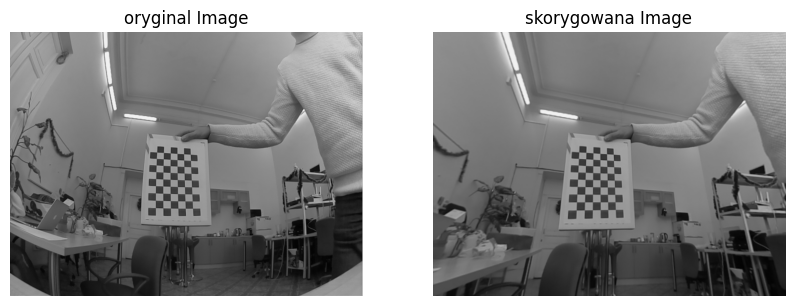

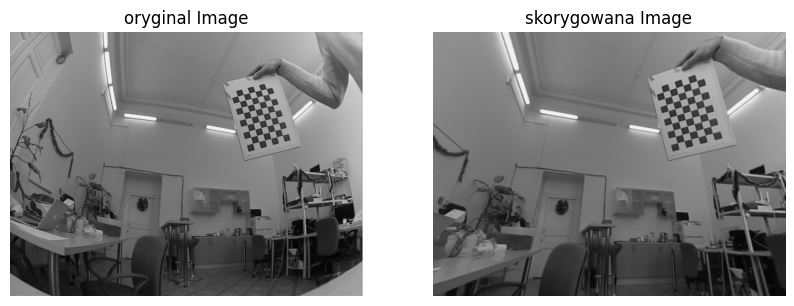

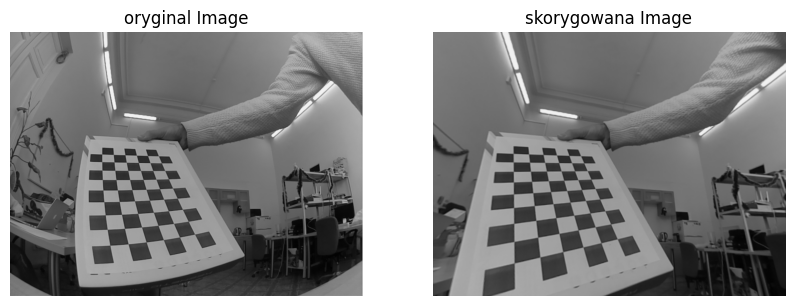

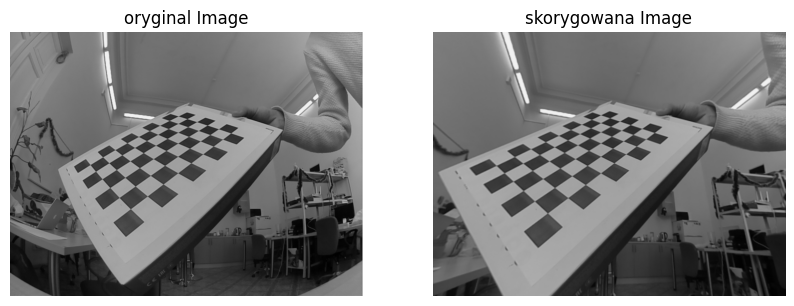

In [9]:
index_image_to_show = [0, 14, 20, 28, 39, 44, 48]

for i in index_image_to_show:    
    fig, ax = plt.subplots(1, 2, figsize=(10, 7))
    ax[0].set_title("oryginal Image")
    ax[0].imshow(cv2.cvtColor(corected_images_left[i][0], cv2.COLOR_BGR2RGB))
    ax[0].axis("off")
    ax[1].imshow(cv2.cvtColor(corected_images_left[i][1], cv2.COLOR_BGR2RGB))
    ax[1].set_title("skorygowana Image")
    ax[1].axis("off")
    plt.show()

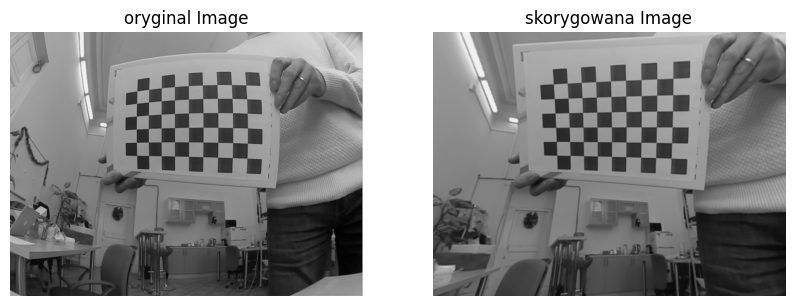

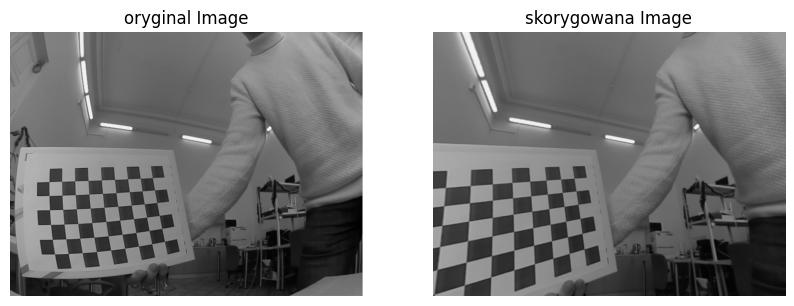

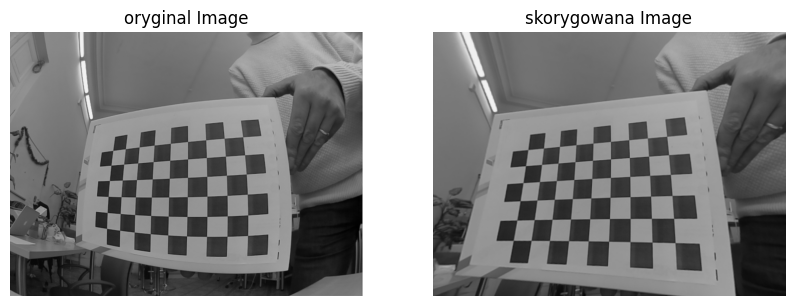

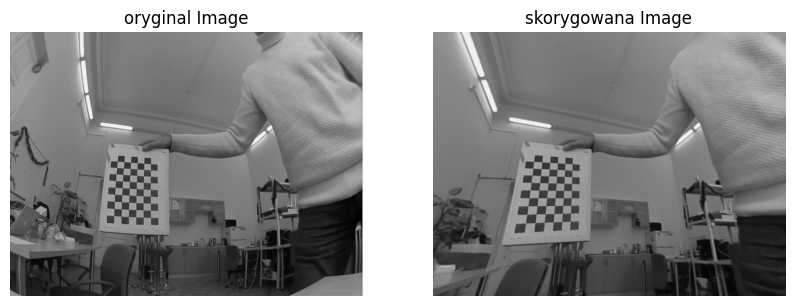

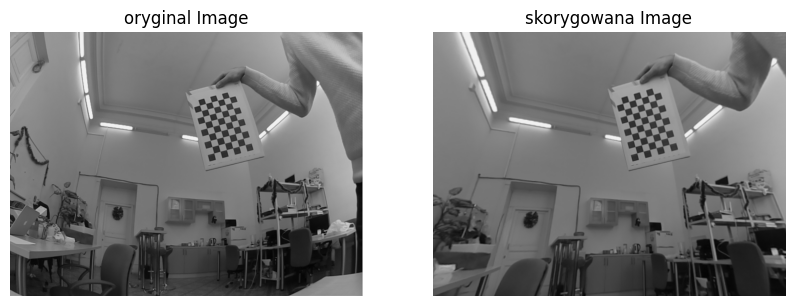

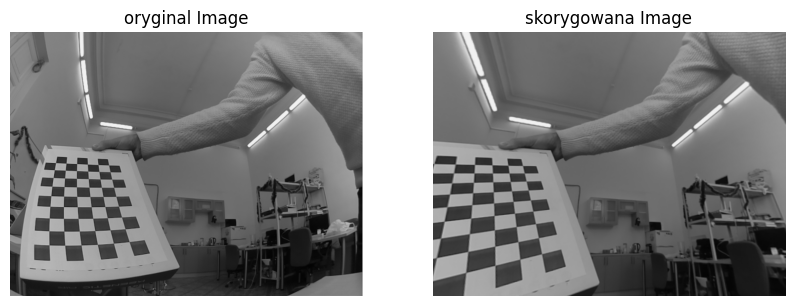

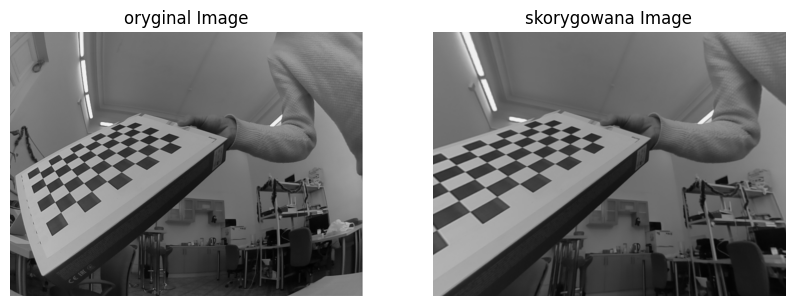

In [10]:
index_image_to_show = [0, 14, 20, 28, 39, 44, 48]

for i in index_image_to_show:    
    fig, ax = plt.subplots(1, 2, figsize=(10, 7))
    ax[0].set_title("oryginal Image")
    ax[0].imshow(cv2.cvtColor(corected_images_right[i][0], cv2.COLOR_BGR2RGB))
    ax[0].axis("off")
    ax[1].imshow(cv2.cvtColor(corected_images_right[i][1], cv2.COLOR_BGR2RGB))
    ax[1].set_title("skorygowana Image")
    ax[1].axis("off")
    plt.show()